EfficientNet Implementation 

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import json

# setting the randomness 
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\nlibraries loaded!!")


libraries loaded!!


Loading the Data 

In [3]:
from tensorflow.keras.applications.efficientnet import preprocess_input

output_path = r"C:\Users\hp\Downloads\content\lung-disease-split"

train_path = os.path.join(output_path, "train")
val_path = os.path.join(output_path, "val")
test_path  = os.path.join(output_path, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# EfficientNet needs preprocess_input NOT rescale
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range  = 15,    
    width_shift_range  = 0.10,     
    height_shift_range  = 0.10,     
    horizontal_flip = True,      
    zoom_range  = 0.10       
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical",
    shuffle = True,
    seed   = SEED
)

val_data = val_test_datagen.flow_from_directory(
    val_path,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode= "categorical",
    shuffle = False
)

test_data = val_test_datagen.flow_from_directory(
    test_path,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode= "categorical",
    shuffle = False
)

classes = list(train_data.class_indices.keys())
num_classes = len(classes)

print(f"Classes found: {classes}")
print(f"Train images: {train_data.samples}")
print(f"Val images  : {val_data.samples}")
print(f"Test images : {test_data.samples}")

Found 2428 images belonging to 3 classes.
Found 520 images belonging to 3 classes.
Found 522 images belonging to 3 classes.
Classes found: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train images: 2428
Val images  : 520
Test images : 522


Compute Class Weights 

In [4]:
# weights for each class 
raw_weights = compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(train_data.classes),
    y = train_data.classes
)
class_weight_dict = dict(enumerate(raw_weights))

print("Class weights:")
for cls, w in zip(classes, raw_weights):
    print(f"{cls:<25}   weight = {w:.4f}")

Class weights:
Lung_Opacity                weight = 1.0284
Normal                      weight = 0.9250
Viral Pneumonia             weight = 1.0566


Building the Model


In [5]:
# teaching the model abt our data 
base_model = tf.keras.applications.EfficientNetB0(
    weights = "imagenet",    
    include_top = False,          
    input_shape = (224, 224, 3)  
)

# freezing base to protect the pretrained knowledge 
base_model.trainable = False

# Build full model on top
model = models.Sequential([
    base_model,                                     
    layers.GlobalAveragePooling2D(),                
    layers.BatchNormalization(),                  
    layers.Dense(256, activation="relu"),            
    layers.Dropout(0.4), # preventing the memorization                       
    layers.Dense(num_classes, activation="softmax") 
], name="EfficientNetB0_Classifier")

# Compile
model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-3),
    loss  = "categorical_crossentropy",
    metrics = ["accuracy"]
)

model.summary()
print("Model built successfully!")

Model: "EfficientNetB0_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,398 (16.72 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Model built successfully!


Phase 1 - Train the top layers with the base model frozen

In [6]:

# Safety checks during training
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3),
    tf.keras.callbacks.ModelCheckpoint(
            filepath=f"efficientnet_phase1_best.keras",
            monitor="val_accuracy", save_best_only=True, verbose=1
        )
]

print("Phase 1 Training new layers ")

history_p1 = model.fit(
    train_data,      # images to learn form 
    epochs = 10,    # going thru all images 10 times 
    validation_data = val_data, # aftr each epoch test on validation images 
    class_weight = class_weight_dict, # check the weights on each class 
    callbacks = callbacks, # safety checks 
    verbose = 1 # process line for each epoch 
)
 
print("Phase 1 completed !")

Phase 1 Training new layers 
Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7613 - loss: 0.7023
Epoch 1: val_accuracy improved from None to 0.87692, saving model to efficientnet_phase1_best.keras

Epoch 1: finished saving model to efficientnet_phase1_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.8233 - loss: 0.5394 - val_accuracy: 0.8769 - val_loss: 0.3338 - learning_rate: 0.0010
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8639 - loss: 0.4125
Epoch 2: val_accuracy improved from 0.87692 to 0.90192, saving model to efficientnet_phase1_best.keras

Epoch 2: finished saving model to efficientnet_phase1_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - accuracy: 0.8769 - loss: 0.3482 - val_accuracy: 0.9019 - val_loss: 0.2660 - learning_rate: 0.0010
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8799 - loss: 0.3215
Epoch 3: val_accuracy did not improve from 0.90192
76/76 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.88

Plotting Training Curves

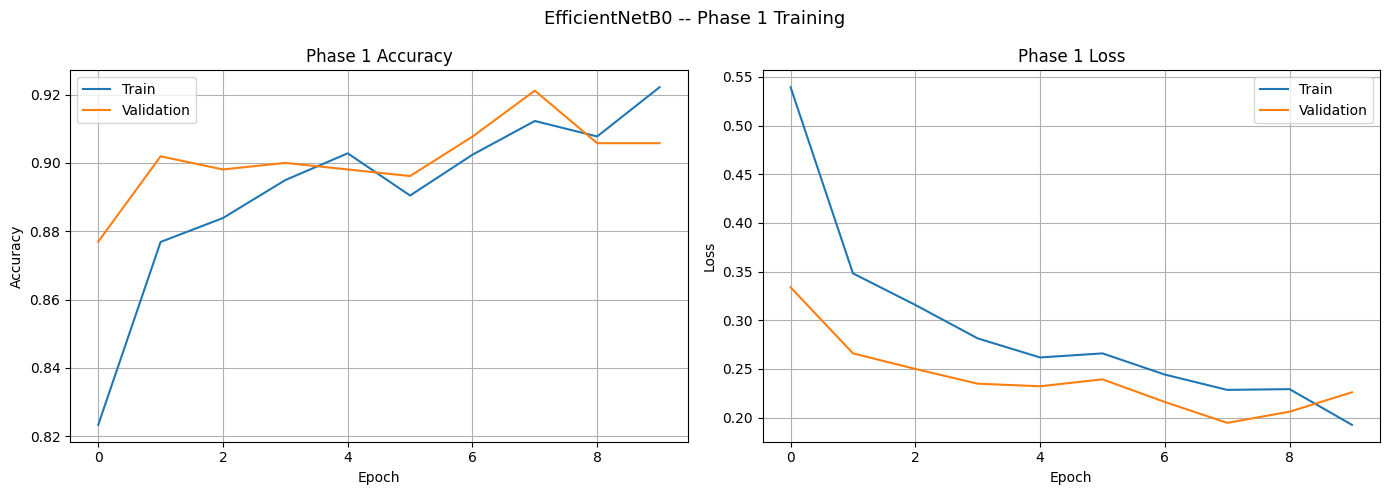

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_p1.history["accuracy"],label="Train")
axes[0].plot(history_p1.history["val_accuracy"], label="Validation")
axes[0].set_title("Phase 1 Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_p1.history["loss"],label="Train")
axes[1].plot(history_p1.history["val_loss"], label="Validation")
axes[1].set_title("Phase 1 Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("EfficientNetB0 -- Phase 1 Training", fontsize=13)
plt.tight_layout()
plt.show()

Phase 2 - Unfreeze the base model and fine-tune

In [8]:
print("Phase 2 Fine tuning top 20 layers")

# Unfreeze the entire base first
base_model.trainable = True

# refreeze everything but not the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with much smaller learning rate
model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-5),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

# safety checks 
callbacks_p2 = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("efficientnet_phase2_best.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
]

history_p2 = model.fit(
    train_data, # images to learn from 
    epochs = 20, # going thru every image 20 times 
    validation_data = val_data, # aftr each epoch test on validation images 
    class_weight = class_weight_dict, # check weights of every class 
    callbacks  = callbacks_p2, # safety checks 
    verbose= 1 # process line for each epoch 
)

print("Phase 2 completed !")

Phase 2 Fine tuning top 20 layers
Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8104 - loss: 0.4859
Epoch 1: val_accuracy improved from None to 0.89808, saving model to efficientnet_phase2_best.keras

Epoch 1: finished saving model to efficientnet_phase2_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.8283 - loss: 0.4194 - val_accuracy: 0.8981 - val_loss: 0.2538 - learning_rate: 1.0000e-05
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8632 - loss: 0.3452
Epoch 2: val_accuracy did not improve from 0.89808
76/76 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8629 - loss: 0.3411 - val_accuracy: 0.8962 - val_loss: 0.2639 - learning_rate: 1.0000e-05
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8784 - loss: 0.2924
Epoch 3: val_accuracy improved from 0.89808 to 0.90000, saving model to efficientnet_phase2_best.keras

Epoch 3: finished saving model to efficientnet_phase2_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - a

Plotting Training Curves

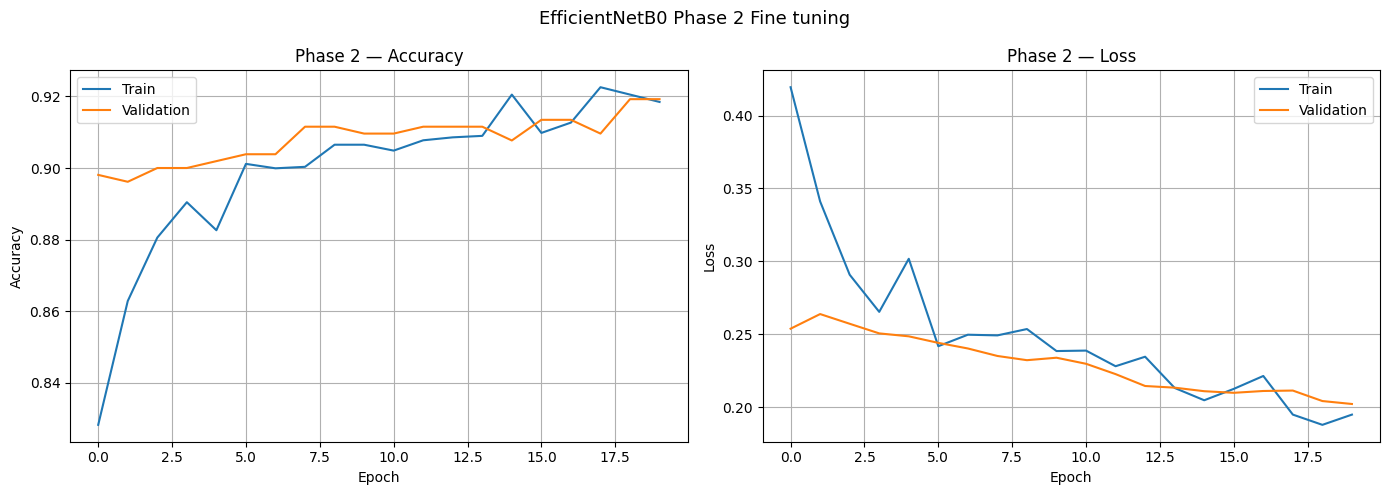

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_p2.history["accuracy"], label="Train")
axes[0].plot(history_p2.history["val_accuracy"], label="Validation")
axes[0].set_title("Phase 2 — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_p2.history["loss"], label="Train")
axes[1].plot(history_p2.history["val_loss"], label="Validation")
axes[1].set_title("Phase 2 — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("EfficientNetB0 Phase 2 Fine tuning", fontsize=13)
plt.tight_layout()
plt.show()

Evaluating the Model on Test set 

In [ ]:
print("Evaluating on test set ")

test_data.reset()
loss, accuracy = model.evaluate(test_data, verbose=0)
print(f"\nTest Loss   : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

# get predictions
test_data.reset()
predictions = model.predict(test_data, verbose=0)
y_pred  = np.argmax(predictions, axis=1)
y_true = test_data.classes[:len(y_pred)]

# classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred,target_names=classes))

Evaluating on test set 

Test Loss : 0.3106
Test Accuracy : 0.8774 (87.74%)

Classification Report:
                 precision    recall  f1-score   support

   Lung_Opacity       0.81      0.88      0.84       169
         Normal       0.86      0.80      0.83       188
Viral Pneumonia       0.97      0.96      0.97       165

       accuracy                           0.88       522
      macro avg       0.88      0.88      0.88       522
   weighted avg       0.88      0.88      0.88       522



Confusion Matrix 

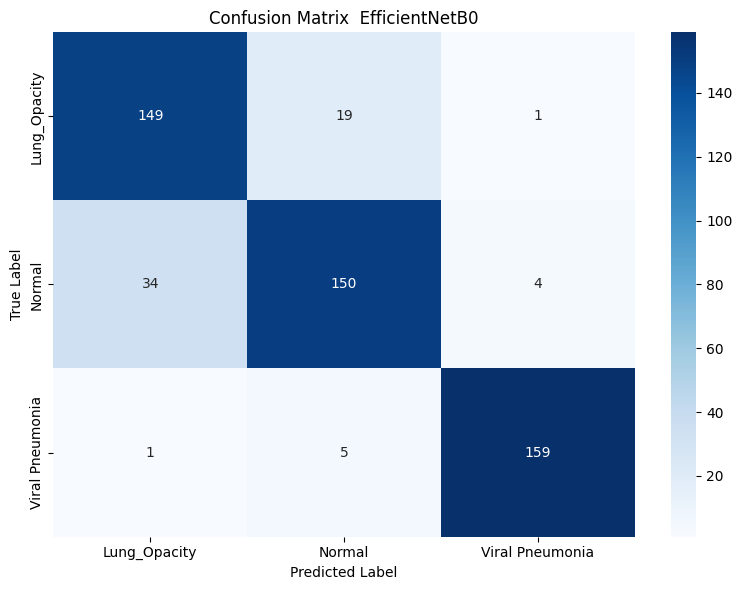

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix  EfficientNetB0")
plt.tight_layout()
plt.show()

Saving the Model

In [12]:
# Save the trained model
model.save("efficientnetb0_final.keras")
print("Model saved as efficientnetb0_final.keras")

# Save class names  
with open("class_names.json", "w") as f:
    json.dump(classes, f)
print("Class names saved as class_names.json") 
print(f"Classes: {classes}")

Model saved as efficientnetb0_final.keras
Class names saved as class_names.json
Classes: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
